Importing Packages

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()




Loading and transforming the data to required form

In [50]:
raw_data = pd.read_csv("./datasets/Index2018.csv")
comp_df = raw_data.copy()
comp_df.date = pd.to_datetime(comp_df.date, dayfirst=True)
comp_df.set_index("date", inplace=True)
comp_df=comp_df.asfreq("b")
comp_df = comp_df.fillna(method="ffill")

C:\Users\USER\AppData\Local\Temp\ipykernel_12240\2213365833.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  comp_df = comp_df.fillna(method="ffill")


Removing surplus and splitting the data

In [51]:
comp_df["market_Price"] = comp_df.spx
comp_df.head()

,spx,dax,ftse,nikkei,market_Price
date,,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01,469.90
1994-01-10,475.27,2225.00,3440.58,18443.44,475.27
1994-01-11,474.13,2228.10,3413.77,18485.25,474.13
1994-01-12,474.17,2182.06,3372.02,18793.88,474.17
1994-01-13,472.47,2142.37,3360.01,18577.26,472.47


In [52]:

del comp_df ["dax"]
del comp_df["spx"]
del comp_df["ftse"]
del comp_df["nikkei"]

size = int(len(comp_df) * 0.8)
df,test_df = comp_df.iloc[:size],comp_df.iloc[size:]

 

Generating White Noise

In [53]:
wn = np.random.normal(loc = df.market_Price.mean(),scale = df.market_Price.std(),size = len(df))

In [54]:
df["wn"] = wn

C:\Users\USER\AppData\Local\Temp\ipykernel_12240\617207721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["wn"] = wn


In [55]:
df.head()

,market_Price,wn
date,,
1994-01-07,469.90,1180.578760
1994-01-10,475.27,677.755192
1994-01-11,474.13,1326.564619
1994-01-12,474.17,1010.379496
1994-01-13,472.47,1534.286198


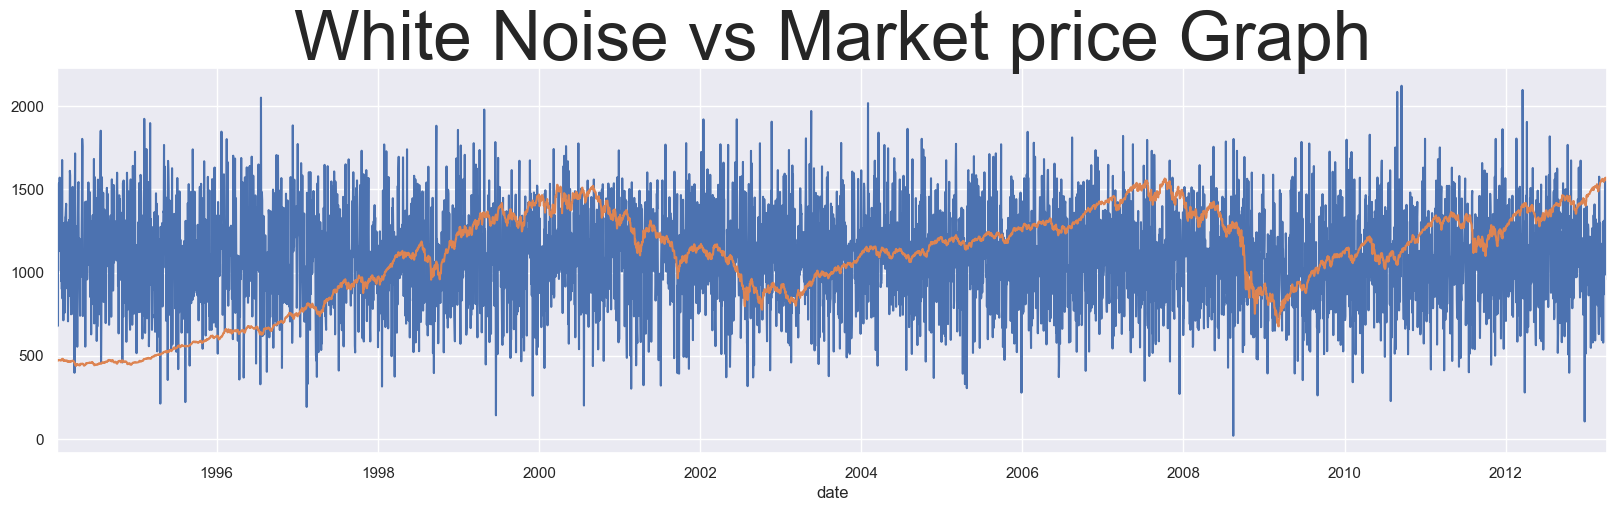

In [56]:
df.wn.plot(figsize=(20,5))
df.market_Price.plot(figsize=(20,5))
plt.title("White Noise vs Market price Graph", size= 50)
plt.show()